#### Exploratory Data Analysis

This exploratory data analysis (EDA) focuses on understanding the patterns, relationships, and key characteristics of the cleaned farm environmental dataset. The dataset was pre-processed to handle missing values, correct inconsistencies, and ensure spatial alignment across all variables. Additional features such as slope, longitude , latitude, coastal, and raparian were also structured to support deeper analysis.

The purpose of this EDA is to examine the distribution of environmental variables, identify trends and potential outliers, and explore relationships between factors such as climate, soil type. Visualisations and summary statistics are used to uncover meaningful insights that can support further modelling and decision-making. This step ensures that the dataset is reliable, well-understood, and suitable for downstream tasks such as predictive modelling or clustering.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Set plot style
sns.set_theme(style="whitegrid")

In [3]:
# load dataset
farms = pd.read_csv("C:/Users/Vasmai/dataset/farm_master.csv")
print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        Clay  6.2      1959         24.0        585     0.36   
1        2        Clay  6.2      1959         24.0        481     0.48   
2        3  Sandy Loam  8.2      2021         25.0        179     1.18   
3        4  Sandy Loam  5.9      2554         24.0        260     0.46   
4        5        Clay  7.0      2021         25.0        129     2.00   

                                            geometry  soil_texture_id  \
0  MULTIPOLYGON (((14101512.969821146 -957413.082...                1   
1  MULTIPOLYGON (((14101967.821260527 -957269.165...                1   
2  MULTIPOLYGON (((14100209.58295843 -965731.0934...                2   
3  MULTIPOLYGON (((14098786.129920498 -965389.142...                2   
4  MULTIPOLYGON (((14100819.287691895 -965879.973...                1   

   coastal      slope   longitude  latitude  riparian  nitrogen_fixing  \
0    False  13.114323  126.675704 -8.56879

In [4]:
print(farms.info())
print(farms.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   farm_id           3200 non-null   int64  
 1   texture           3200 non-null   object 
 2   ph                3200 non-null   float64
 3   rainfall          3200 non-null   int64  
 4   temperature       3200 non-null   float64
 5   elevation         3200 non-null   int64  
 6   area_ha           3200 non-null   float64
 7   geometry          3200 non-null   object 
 8   soil_texture_id   3200 non-null   int64  
 9   coastal           3200 non-null   bool   
 10  slope             3200 non-null   float64
 11  longitude         3200 non-null   float64
 12  latitude          3200 non-null   float64
 13  riparian          3200 non-null   bool   
 14  nitrogen_fixing   3200 non-null   bool   
 15  shade_tolerant    3200 non-null   bool   
 16  bank_stabilising  3200 non-null   bool   


In [5]:
print(farms.isnull().sum())

farm_id             0
texture             0
ph                  0
rainfall            0
temperature         0
elevation           0
area_ha             0
geometry            0
soil_texture_id     0
coastal             0
slope               0
longitude           0
latitude            0
riparian            0
nitrogen_fixing     0
shade_tolerant      0
bank_stabilising    0
dtype: int64


In [6]:
# Select all numeric types (floats and integers)
farms_num_cols = farms.select_dtypes(include=[np.number]).columns.tolist()

# Remove the id column
farms_num_cols.remove("farm_id")

# Convert the 'soil_texture' column to lowercase
farms["texture"] = farms["texture"].str.lower()

# Select object  types
farms_cat_cols = farms.select_dtypes(include=["object", "bool"]).columns.tolist()

print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  soil_texture_id  \
0  MULTIPOLYGON (((14101512.969821146 -957413.082...                1   
1  MULTIPOLYGON (((14101967.821260527 -957269.165...                1   
2  MULTIPOLYGON (((14100209.58295843 -965731.0934...                2   
3  MULTIPOLYGON (((14098786.129920498 -965389.142...                2   
4  MULTIPOLYGON (((14100819.287691895 -965879.973...                1   

   coastal      slope   longitude  latitude  riparian  nitrogen_fixing  \
0    False  13.114323  126.675704 -8.56879

#### Numerical Variable Distribution(Histogram)

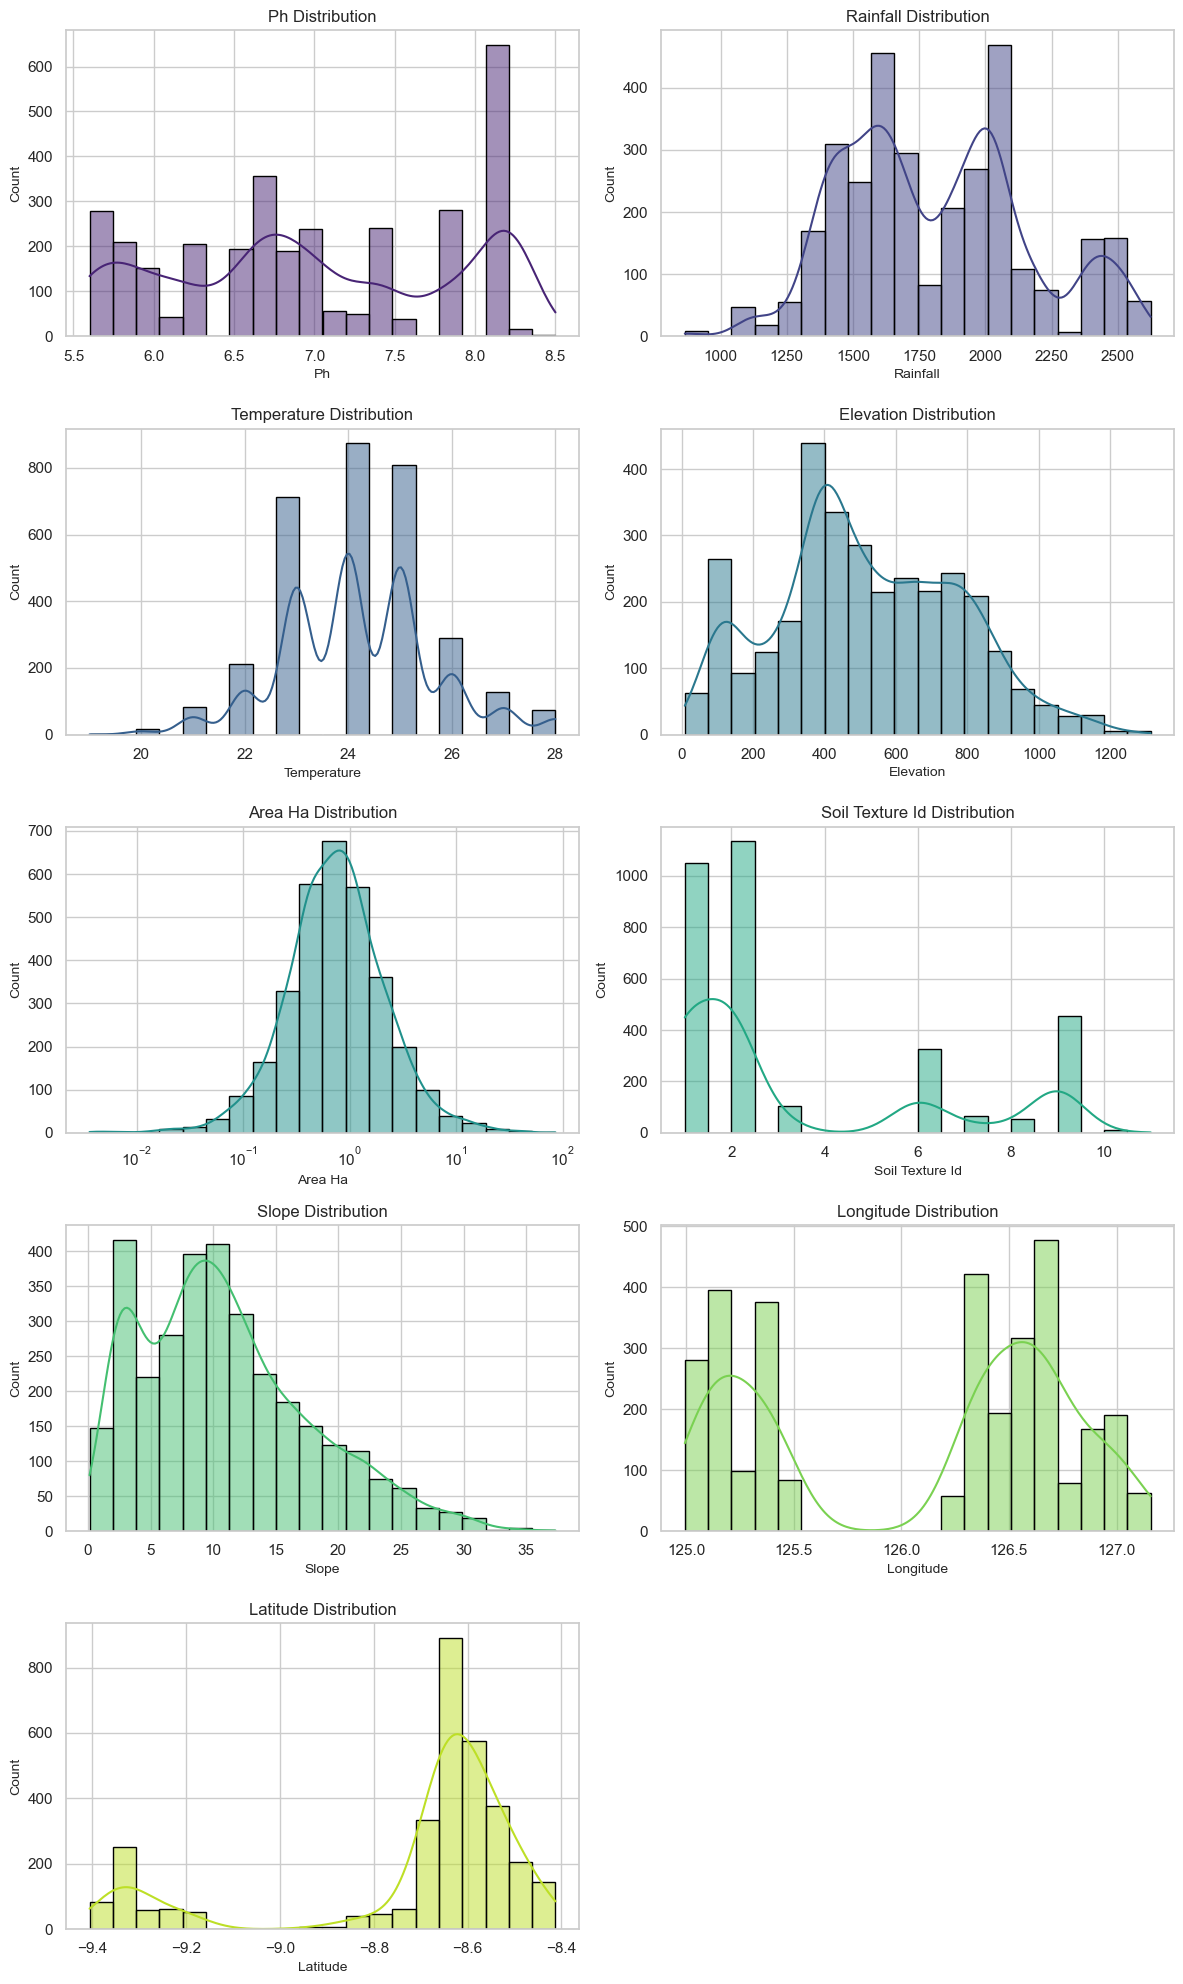

In [13]:
# Dynamic grid calculation
num_plots = len(farms_num_cols)
cols_grid = 2
rows_grid = math.ceil(num_plots / cols_grid)

# Choose a color palette
colors = sns.color_palette("viridis", num_plots)

# List of skewed numeric columns to apply log scale
skewed_cols = ["area_ha"]  # you can add more if needed

# Create figure
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_num_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)

    # Add log_scale=(True, False) if column is skewed
    if col in skewed_cols:
        sns.histplot(farms[col], kde=True, color=colors[i], bins=20, edgecolor="black", log_scale=(True, False))
    else:
        sns.histplot(farms[col], kde=True, color=colors[i], bins=20, edgecolor="black")

    plt.title(f"{col.replace('_', ' ').title()} Distribution", fontsize=12)
    plt.xlabel(col.replace("_", " ").title(), fontsize=10)
    plt.ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

#### Insight

##### pH: 
pH values are moderately spread and slightly multi-modal, indicating variation in soil acidity across farms.

##### Rainfall: 
Rainfall shows slight right skewness, with most farms receiving moderate rainfall and a few experiencing very high levels.

##### Temperature: 
Temperature is tightly clustered, indicating very similar climatic conditions across all farms.

##### Elevation: 
Elevation is right-skewed, with most farms located at lower to mid altitudes and fewer at higher elevations.

##### Area-ha:
Appears roughly symmetric on the log scale,indicating most farms cluster around a typical size with fewer very small or ery large farms

##### Soil_texture_ID:
Highly clusterd by 1-2 with smaller peaks around 6-10, showing uneven represntation of soil types

##### Slope: 
Slope values are right-skewed, indicating most farms have gentle slopes while some are on steeper terrain.

##### Longitude: 
Longitude is narrowly distributed, confirming farms are located within a limited horizontal geographic range.

##### Latitude: 
Latitude is tightly clustered, indicating farms are concentrated within a specific vertical geographic region.

#### Summary
The numerical analysis shows that while variables like temperature and location are consistent, others such as rainfall, elevation, area ha, slope, and farm size vary significantly. Several variables exhibit skewness and outliers, which may require preprocessing techniques such as scaling or transformation before modelling.

### Categorical Distribution

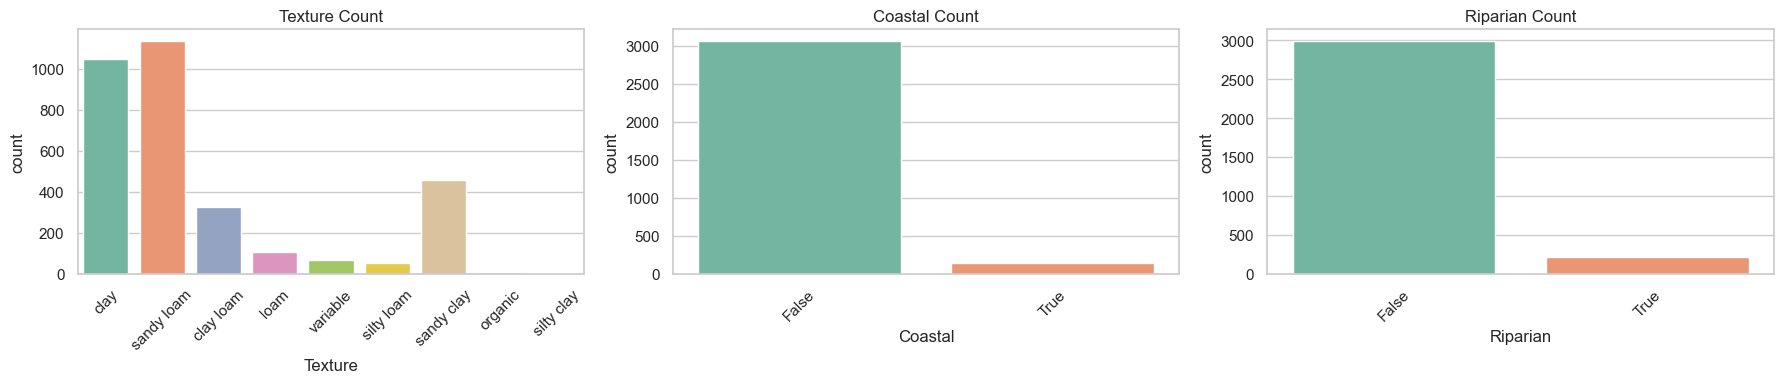

In [14]:
# Columns to exclude from categorical plots
exclude_cols = ["nitrogen_fixing", "shade_tolerant", "bank_stabilising"]

# Select categorical columns with less than 20 unique values, excluding placeholders
categorical_cols = [col for col in farms_cat_cols if farms[col].nunique() < 20 and col not in exclude_cols]

num_plots = len(categorical_cols)
cols = 3  # number of plots per row
rows = (num_plots + cols - 1) // cols  # calculate number of rows needed

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()  # flatten for easy indexing

# Plot each categorical column
for i, column in enumerate(categorical_cols):
    sns.countplot(data=farms, x=column, hue=column, palette="Set2", ax=axes[i], dodge=False, legend=False)
    axes[i].set_title(f"{column.replace('_', ' ').title()} Count")
    axes[i].set_xlabel(column.replace("_", " ").title())
    axes[i].tick_params(axis="x", rotation=45)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Insight

The categorical features of the farm dataset were analyzed to understand distribution patterns and location-based characteristics. In the texture column, sandy loam is the most frequent soil type, while other types like clay loam and organic are less common. The derived coastal feature, which labels farms with elevation below 100 m and moderate rainfall (500–3500 mm) as coastal, shows that most farms are inland (coastal=False). Similarly, the riparian feature identifies farms intersecting a 15 m buffer around waterways, with only a small subset of farms labeled True, and vast majority of observations labeled false. These patterns indicate that the majority of farms are inland, predominantly sandy loam, and located away from major waterways, which may influence both environmental conditions and management practices.

#### Heatmap

##### The actual correlation values between numeric variables

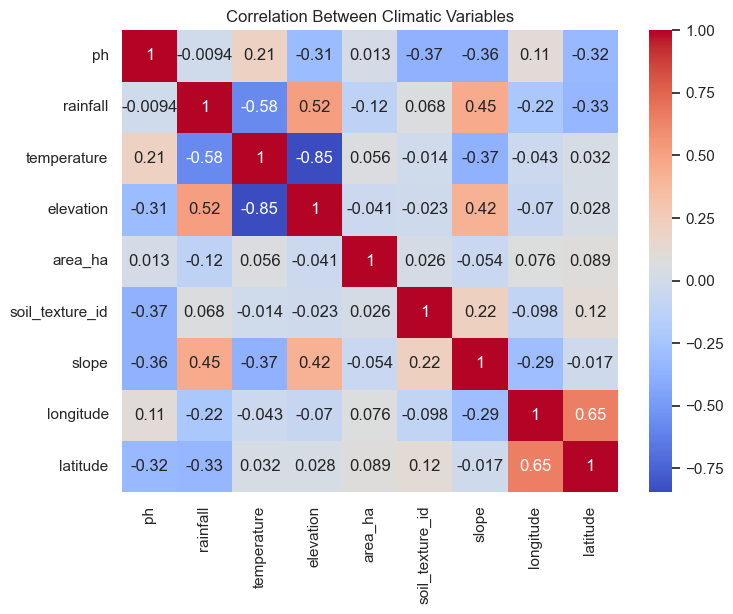

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(farms[farms_num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Climatic Variables")
plt.show()

#### Key Positive Correlations
Rainfall & Elevation: 0.52 → higher elevation farms tend to receive more rainfall.

Longitude & Latitude: 0.65 → the farm locations are spatially aligned in a specific geographic pattern.

#### Key Negative Correlations
Temperature & Elevation: -0.85 → higher altitude farms are significantly cooler.

Temperature & Rainfall: -0.58 → higher rainfall areas tend to have slightly lower temperatures.

Soil Texture ID & pH (r = -0.37): As soil texture ID increases (coarser or sandier soils), pH tends to decrease slightly.

#### Weak or No Correlation
pH shows very low correlation with all other variables (between -0.36 and 0.21) → pH varies independently.

Area (ha): Almost no correlation with other variables → farm size is independent of elevation, rainfall, slope, or soil type.

Soil Texture ID: Aside from its negative correlation with pH, it has weak correlations with climatic and spatial variables → mostly independent.

#### Overall Observations
Elevation strongly affects temperature and moderately affects rainfall.

Spatial variables (latitude and longitude) are moderately correlated, showing farms are geographically aligned.

Soil texture has a slight negative relationship with pH but is otherwise independent, while pH and farm area vary largely independently.

#### Insight

Correlation analysis indicates that temperature decreases significantly with elevation (r = -0.85), and rainfall moderately increases with elevation (r = 0.52). Latitude and longitude are moderately correlated (r = 0.65), reflecting farm spatial patterns. Soil texture ID shows a moderate negative correlation with pH (r = -0.37), meaning coarser soils tend to be slightly more acidic. Other variables, including farm area, show very weak correlations.

### Clustering

#### Numeric features for clustering

In [18]:
# Exclude ID, geometry, longitude/latitude (keep only climate-related numeric features)
exclude_cols = ["farm_id", "geometry", "longitude", "latitude", "Farm_Archetype", "soil_texture_id"]
farms_num_cols = [col for col in farms.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

print("Numeric features used for clustering:", farms_num_cols)

Numeric features used for clustering: ['ph', 'rainfall', 'temperature', 'elevation', 'area_ha', 'slope']


In [25]:
# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(farms[farms_num_cols])

print("Shape of scaled data:", X_scaled.shape)

Shape of scaled data: (3200, 6)


In [32]:
# Step 1: Determine optimal k using silhouette scores
silhouette_scores = []
k_values = range(2, 11)  # test k from 2 to 10

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Select k with the highest silhouette score
optimal_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal k from silhouette analysis: {optimal_k}")

# Step 2: Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
farms["Farm_Archetype"] = kmeans.fit_predict(X_scaled)

# Step 3: Get cluster centroids in original scale
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),  # inverse scale to original units
    columns=farms_num_cols,
)
print("Farm Archetype Profiles (Centroids):")
print(centroids)

Optimal k from silhouette analysis: 2
Farm Archetype Profiles (Centroids):
         ph     rainfall  temperature   elevation   area_ha      slope
0  7.256090  1622.357906    25.003739  365.142628  1.671890   7.509786
1  6.598268  2069.101657    23.052711  731.984940  1.049266  15.834369


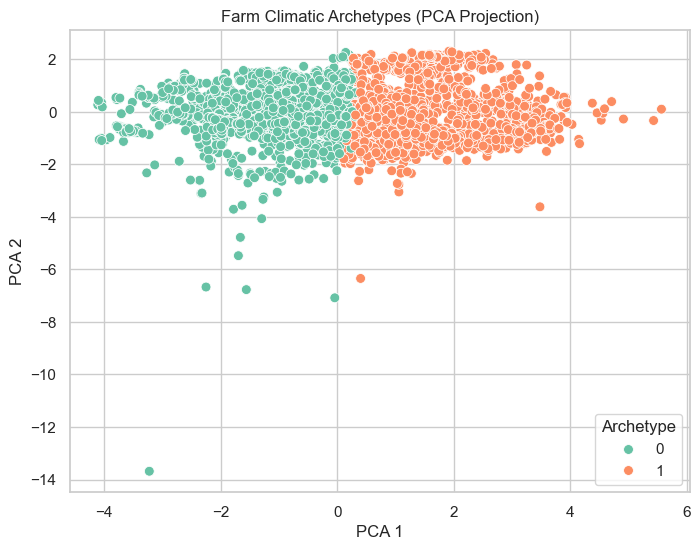

Number of farms per archetype:
Farm_Archetype
0    1868
1    1332
Name: count, dtype: int64
Number of numeric columns used: 6
Shape of cluster centers: (2, 6)


In [33]:
# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=farms["Farm_Archetype"], palette="Set2", s=50)
plt.title("Farm Climatic Archetypes (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Archetype")
plt.show()

print("Number of farms per archetype:")
print(farms["Farm_Archetype"].value_counts())

print("Number of numeric columns used:", len(farms_num_cols))
print("Shape of cluster centers:", kmeans.cluster_centers_.shape)

### Climatic Archetypes Analysis Insight

Performed K-Means clustering on six climate-related numeric variables—pH, rainfall, temperature, elevation, area, and slope—after standardizing the data. The optimal number of clusters, determined using the silhouette score, was 2, indicating 2 distinct farm climatic archetypes.

##### Archetype Profiles (Centroids):

##### Archetype 0: 
Moderately neutral soils (pH 7.26), lower rainfall (1622 mm), warmer temperatures (25.0 °C), lower elevation (365 m), larger farm area (1.67 ha), gentle slopes (7.5°).

##### Archetype 1:
Slightly acidic soils (pH 6.60), higher rainfall (2069 mm), cooler temperatures (23.1 °C), higher elevation (732 m), smaller farm area (1.05 ha), steeper slopes (15.8°).


##### Distribution of Farms:

Archetype 0: 1868 farms
Archetype 1: 1332 farms

Most farms belong to Archetype 0, located in warmer, lower-elevation areas with larger farm sizes and gentle slopes, whereas Archetype 1 farms are in higher-elevation, cooler regions with smaller areas and steeper slopes.

##### Visualization:
PCA projection confirms clear separation between the two clusters, highlighting distinct climatic profiles. The first two principal components capture the majority of variation in climate-related features, supporting the robustness of the clustering.

##### Key Insight:

Farms can be classified into two meaningful climatic archetypes, which can inform targeted agricultural practices, resource allocation, and crop suitability analysis.

Interventions for Archetype 0 will impact the largest number of farms.
Archetype 1 may require more location-specific strategies due to its smaller size and unique high-elevation characteristics.

### Categorical analysis to complement climatic archetypes

In [34]:
# Select relevant categorical columns
farms_cat_cols = ["texture", "coastal", "riparian"]

# Quick check
for col in farms_cat_cols:
    print(col, farms[col].value_counts())

texture texture
sandy loam    1135
clay          1049
sandy clay     456
clay loam      325
loam           105
variable        66
silty loam      53
organic         10
silty clay       1
Name: count, dtype: int64
coastal coastal
False    3060
True      140
Name: count, dtype: int64
riparian riparian
False    2987
True      213
Name: count, dtype: int64


#### Count categorical features per archetype

In [35]:
# For each archetype, see distribution of categories
for col in farms_cat_cols:
    print(f"\nDistribution of {col} by Farm Archetype:\n")
    print(pd.crosstab(farms["Farm_Archetype"], farms[col], margins=True))


Distribution of texture by Farm Archetype:

texture         clay  clay loam  loam  organic  sandy clay  sandy loam  \
Farm_Archetype                                                           
0                749        227    99       10         171         538   
1                300         98     6        0         285         597   
All             1049        325   105       10         456        1135   

texture         silty clay  silty loam  variable   All  
Farm_Archetype                                          
0                        1          11        62  1868  
1                        0          42         4  1332  
All                      1          53        66  3200  

Distribution of coastal by Farm Archetype:

coastal         False  True   All
Farm_Archetype                   
0                1728   140  1868
1                1332     0  1332
All              3060   140  3200

Distribution of riparian by Farm Archetype:

riparian        False  True   All
Farm

#### Plot Categorical features per archetype

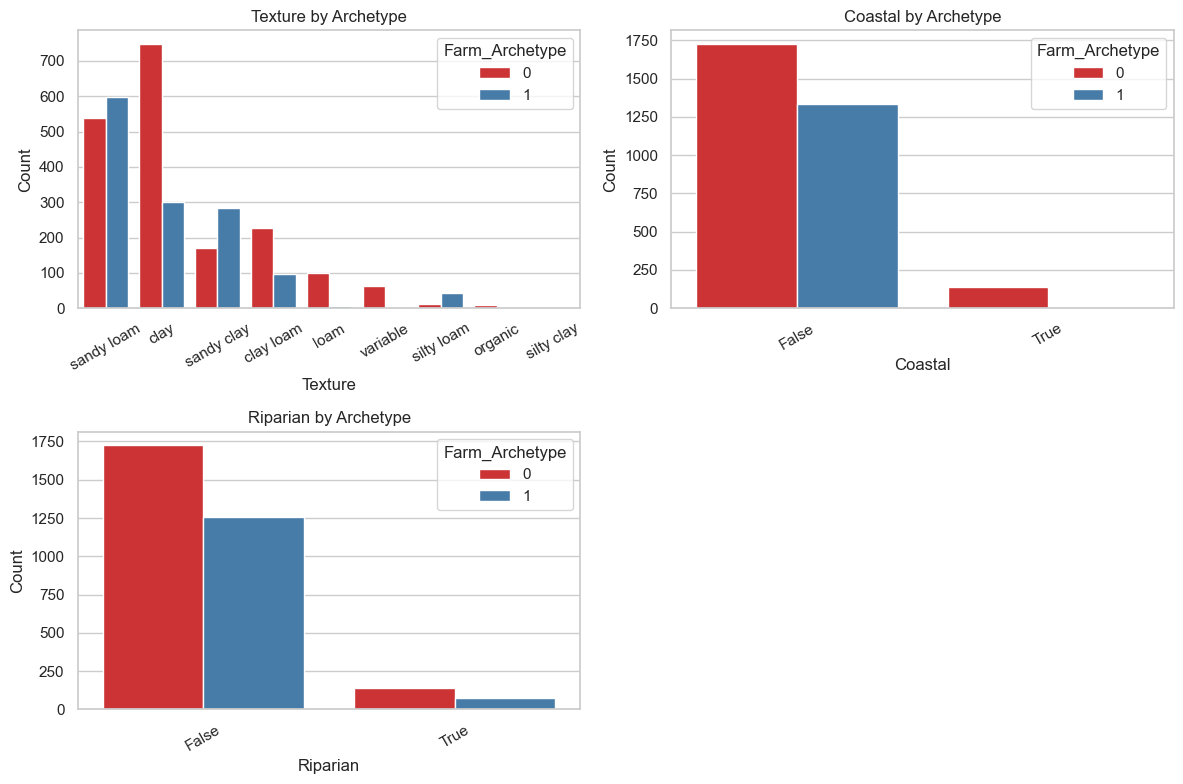

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  soil_texture_id  \
0  MULTIPOLYGON (((14101512.969821146 -957413.082...                1   
1  MULTIPOLYGON (((14101967.821260527 -957269.165...                1   
2  MULTIPOLYGON (((14100209.58295843 -965731.0934...                2   
3  MULTIPOLYGON (((14098786.129920498 -965389.142...                2   
4  MULTIPOLYGON (((14100819.287691895 -965879.973...                1   

   coastal      slope   longitude  latitude  riparian  nitrogen_fixing  \
0    False  13.114323  126.675704 -8.56879

In [36]:
cols_grid = 2
rows_grid = math.ceil(len(farms_cat_cols) / cols_grid)
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_cat_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)
    sns.countplot(data=farms, x=col, hue="Farm_Archetype", palette="Set1", order=farms[col].value_counts().index)
    plt.title(f"{col.title()} by Archetype")
    plt.xlabel(col.title())
    plt.ylabel("Count")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(farms.head())

# Categorical Features Insights by Climatic Archetype

We analyzed three categorical features—soil texture, coastal presence, and riparian proximity—across the two farm climatic archetypes to understand their landscape and environmental patterns.

##### Key Observations:

##### Texture:
Archetype 0: Farms are distributed across clay, clay loam, sandy loam, and some loam soils. This aligns with its moderate elevation, gentler slopes, and larger farm areas.

Archetype 1: Farms show a higher proportion of clay and sandy clay soils, consistent with higher elevation and steeper slopes

##### Coastal:
Archetype 0: Mostly non-coastal, but a small proportion of coastal farms exist (140/1868).

Archetype 1: All farms are non-coastal.

Interpretation: Higher-elevation, steeper farms (Archetype 1) are inland, whereas Archetype 0 includes some farms near the coast.

##### Riparian:
Archetype 0: 140 farms near riparian zones.

Archetype 1: 73 farms near watercourses.

Interpretation: Lower-elevation, gentler-sloped farms (Archetype 0) are more likely to be near riparian zones, while higher-elevation, steeper farms (Archetype 1) are less frequently riparian.

##### Visualization Insights:

Count plots or bar charts would show clear differences in categorical distributions between the two archetypes, confirming that clusters are distinguished not only by numeric climate features but also by environmental characteristics

##### Summary Insight – Categorical Features
Archetype 0: Moderate elevation, gentler slopes, larger farms; mixed soil textures; some coastal and riparian presence.

Archetype 1: Higher elevation, steeper slopes, smaller farms; dominated by clay and sandy clay soils; entirely inland and mostly away from riparian zones.

Farm archetypes differ not only by climate but also by soil type, proximity to water, and coastal location. These patterns can inform location-specific agricultural strategies, such as crop selection, irrigation planning, and soil management.

#### Summarizing both numeric and categorical data for each archetype

In [38]:
# Numeric summary from cluster centers
numeric_summary = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=farms_num_cols).round(2)

# Assign Farm_Archetype explicitly
numeric_summary["Farm_Archetype"] = numeric_summary.index

# Soil texture percentages per archetype
categorical_cols = ["texture"]
cat_summary = pd.crosstab(farms["Farm_Archetype"], farms["texture"])

# Convert counts to percentages
cat_summary_pct = cat_summary.div(cat_summary.sum(axis=1), axis=0).round(2) * 100

# Join numeric + categorical
archetype_profile = numeric_summary.set_index("Farm_Archetype").join(cat_summary_pct)

print(archetype_profile.head())

                  ph  rainfall  temperature  elevation  area_ha  slope  clay  \
Farm_Archetype                                                                 
0               7.26   1622.36        25.00     365.14     1.67   7.51  40.0   
1               6.60   2069.10        23.05     731.98     1.05  15.83  23.0   

                clay loam  loam  organic  sandy clay  sandy loam  silty clay  \
Farm_Archetype                                                                 
0                    12.0   5.0      1.0         9.0        29.0         0.0   
1                     7.0   0.0      0.0        21.0        45.0         0.0   

                silty loam  variable  
Farm_Archetype                        
0                      1.0       3.0  
1                      3.0       0.0  


#### Summary
##### Each row = one archetype, columns = numeric + categorical
The table summarizes numeric and categorical characteristics for each farm archetype.

Archetype 0 (1868 farms)

pH 7.26, rainfall 1622 mm, temperature 25 °C, elevation 365 m, area 1.67 ha, slope 7.5°

Soils: clay 40%, sandy loam 29%, clay loam 12%

Interpretation: Warmer, low-elevation farms with gentle slopes and fertile soils.

Archetype 1 (1332 farms)

pH 6.60, rainfall 2069 mm, temperature 23 °C, elevation 732 m, area 1.05 ha, slope 15.8°

Soils: sandy loam 45%, sandy clay 21%, clay 23%

Interpretation: Cooler, higher-elevation farms with steeper slopes and coarser soils.

##### Key Insight:
Farms differ by climate, elevation, slope, and soil type. 

Archetype 0 covers more farms and represents gentler, fertile regions, while Archetype 1 requires more location-specific management

#### Display 

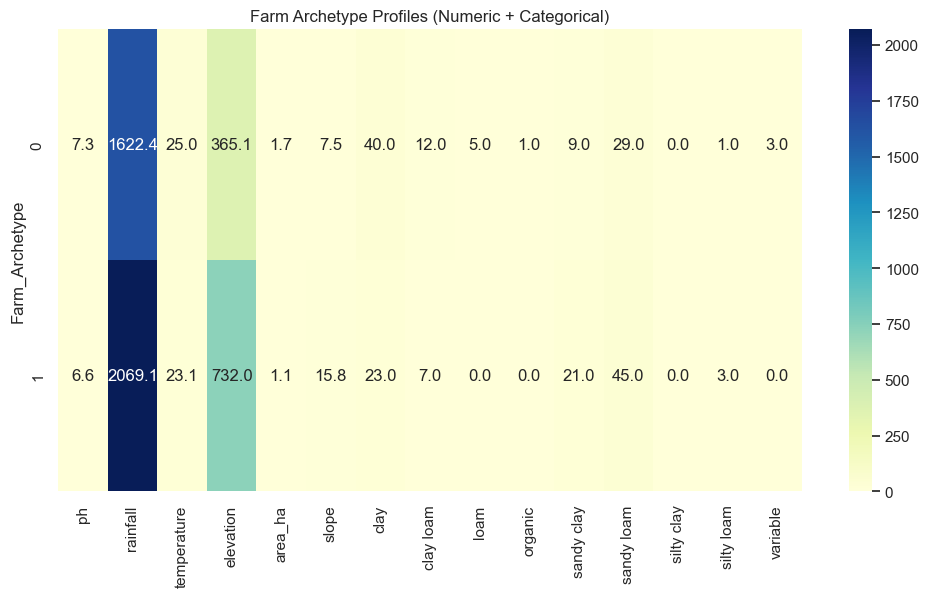

In [39]:
plt.figure(figsize=(12, 6))
sns.heatmap(archetype_profile, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Farm Archetype Profiles (Numeric + Categorical)")
plt.show()

In [40]:
# CSV file path
csv_file_path = os.path.join("C:/Users/Vasmai/dataset", "farm_EDA.csv")
export_cols = [col for col in farms.columns if col != "geometry"]
farms[export_cols].to_csv(csv_file_path, index=False)
# Save cleaned DataFrame directly to CSV
farms.to_csv(csv_file_path, index=False)

print(f"\nClimatic archetypes exported to CSV: {csv_file_path}")


Climatic archetypes exported to CSV: C:/Users/Vasmai/dataset\farm_EDA.csv
